## proses dataset

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Berfungsi untuk Memuat dataset
if 'df' not in globals():
    try:
        df = pd.read_csv('Churn_Modelling.csv')
        print("Dataset 'df' berhasil dimuat.")
    except FileNotFoundError:
        print("Error: File 'Churn_Modelling.csv' tidak ditemukan. Pastikan file berada di direktori yang benar.")
        exit()

print("Dataset berhasil dimuat.")
print(df.head())
print(df.info())

# 1. Data Cleaning
# Memeriksa missing values
print("\nMissing values sebelum pembersihan:\n", df.isnull().sum())

# 2. Feature Engineering dan Splitting Data
# Drop kolom yang tidak relevan atau target variable
X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
y = df['Exited']

# Split data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identifikasi fitur numerik dan kategorikal
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 3. Preprocessing Pipeline
# Preprocessor untuk scaling fitur numerik dan one-hot encoding fitur kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 4. Model Training dan Evaluasi

# Model Random Forest
random_forest_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

random_forest_model_pipeline.fit(X_train, y_train)
y_pred_rf = random_forest_model_pipeline.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAkurasi Model Random Forest: {accuracy_rf:.4f}")

# Hitung probabilitas churn untuk test set
churn_probabilities_rf_test = random_forest_model_pipeline.predict_proba(X_test)[:, 1]

# Model XGBoost
xgboost_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(eval_metric='logloss', random_state=42))
])

xgboost_model_pipeline.fit(X_train, y_train)
y_pred_xgb = xgboost_model_pipeline.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Akurasi Model XGBoost: {accuracy_xgb:.4f}")

# Hitung probabilitas churn untuk test set (digunakan untuk ROC-AUC)
churn_probabilities_xgb_test = xgboost_model_pipeline.predict_proba(X_test)[:, 1]

# Menyimpan variabel-variabel penting ke kernel state agar bisa diakses oleh sel lain
globals()['X'] = X
globals()['y'] = y
globals()['X_train'] = X_train
globals()['X_test'] = X_test
globals()['y_train'] = y_train
globals()['y_test'] = y_test
globals()['preprocessor'] = preprocessor
globals()['random_forest_model_pipeline'] = random_forest_model_pipeline
globals()['xgboost_model_pipeline'] = xgboost_model_pipeline
globals()['accuracy_rf'] = accuracy_rf
globals()['accuracy_xgb'] = accuracy_xgb
globals()['numerical_features'] = numerical_features.tolist()
globals()['categorical_features'] = categorical_features.tolist()
globals()['churn_probabilities_rf_test'] = churn_probabilities_rf_test
globals()['churn_probabilities_xgb_test'] = churn_probabilities_xgb_test

print("\n--- Pelatihan Model Selesai ---")


Dataset 'df' berhasil dimuat.
Dataset berhasil dimuat.
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.

## Visualisasi Eksplorasi Data (EDA)

Bagian ini menampilkan distribusi fitur utama dan hubungannya dengan status *Churn* (Exited).

/tmp/ipykernel_2267/3504410448.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Exited', palette='viridis')


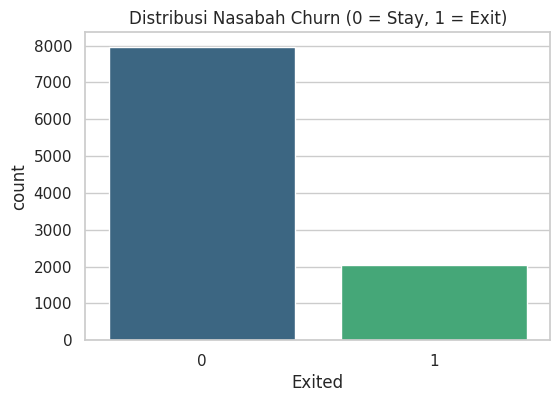

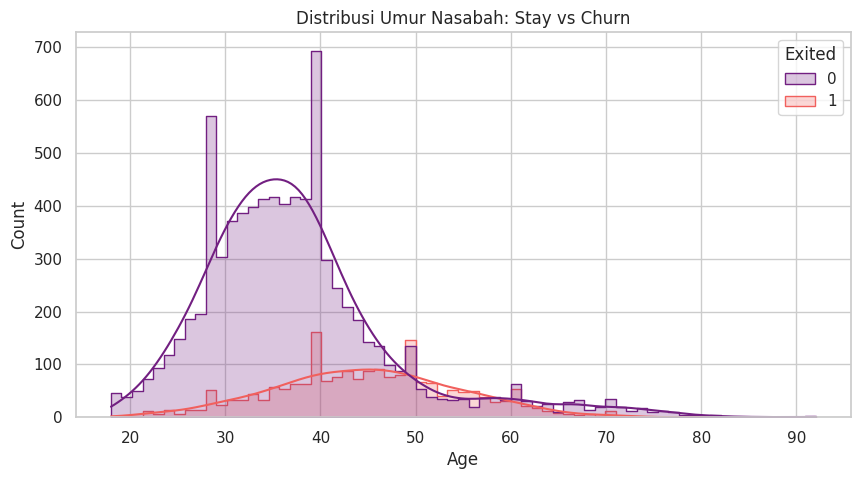

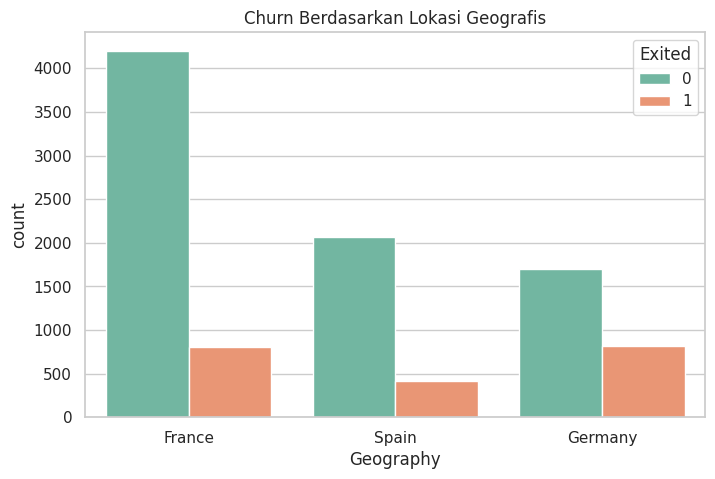

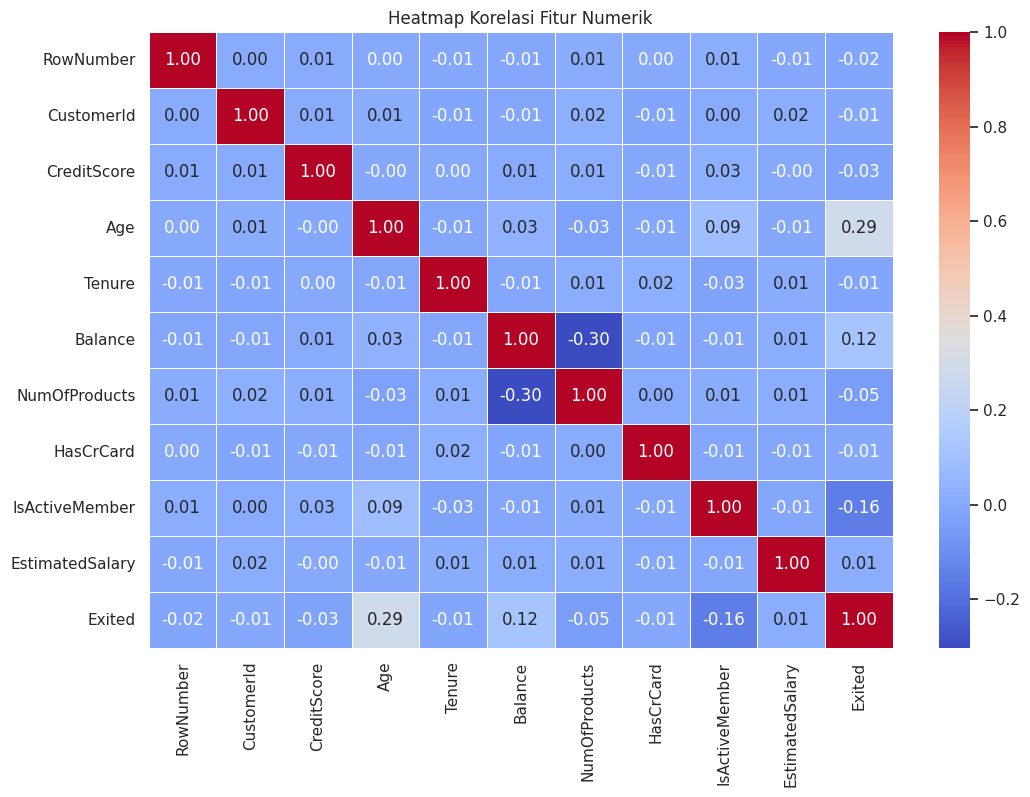

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid")

# 1. Distribusi Target (Exited)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Exited', palette='viridis')
plt.title('Distribusi Nasabah Churn (0 = Stay, 1 = Exit)')
plt.show()

# 2. Distribusi Umur berdasarkan status Churn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Exited', kde=True, element='step', palette='magma')
plt.title('Distribusi Umur Nasabah: Stay vs Churn')
plt.show()

# 3. Hubungan Geography dan Churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Geography', hue='Exited', palette='Set2')
plt.title('Churn Berdasarkan Lokasi Geografis')
plt.show()

# 4. Korelasi antar fitur numerik
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

## table perbandingan sebelum data di proses dan sesudah di proses

In [ ]:
# Before dan after preprocessing data
if 'X' not in globals():
    df = pd.read_csv('Churn_Modelling.csv')
    X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, df['Exited'], test_size=0.2, random_state=42)

print("--- 1. Data Sebelum Preprocessing (Raw Features) ---")
display(X.head())

# Melakukan transformasi untuk demonstrasi
if 'preprocessor' in globals():
    X_train_transformed = preprocessor.transform(X_train)
    column_names = preprocessor.get_feature_names_out()
    df_transformed = pd.DataFrame(X_train_transformed, columns=column_names)

    print("\n--- 2. Data Sesudah Preprocessing (Scaled & Encoded) ---")
    display(df_transformed.head())
else:
    print("\nSilakan jalankan sel pelatihan model (j61uWOpkMR58) terlebih dahulu untuk melihat hasil transformasi.")

--- 1. Data Sebelum Preprocessing (Raw Features) ---


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10



--- 2. Data Sesudah Preprocessing (Scaled & Encoded) ---


,num__CreditScore,num__Age,num__Tenure,num__Balance,num__NumOfProducts,num__HasCrCard,num__IsActiveMember,num__EstimatedSalary,cat__Geography_France,cat__Geography_Germany,cat__Geography_Spain,cat__Gender_Female,cat__Gender_Male
0,0.356500,-0.655786,0.345680,-1.218471,0.808436,0.649203,0.974817,1.367670,1.0,0.0,0.0,0.0,1.0
1,-0.203898,0.294938,-0.348369,0.696838,0.808436,0.649203,0.974817,1.661254,0.0,1.0,0.0,0.0,1.0
2,-0.961472,-1.416365,-0.695393,0.618629,-0.916688,0.649203,-1.025834,-0.252807,0.0,0.0,1.0,0.0,1.0
3,-0.940717,-1.131148,1.386753,0.953212,-0.916688,0.649203,-1.025834,0.915393,1.0,0.0,0.0,1.0,0.0
4,-1.397337,1.625953,1.386753,1.057449,-0.916688,-1.540351,-1.025834,-1.059600,1.0,0.0,0.0,0.0,1.0


## grafik akurasi, dan table hasil prediksi


--- Grafik Akurasi Model ---


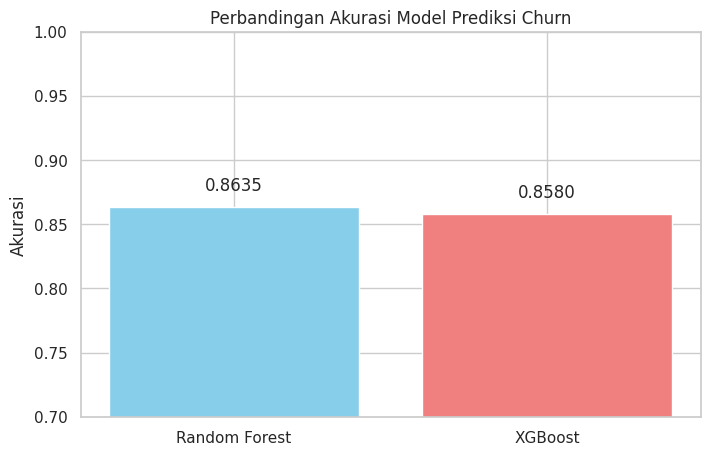


--- Tabel Hasil Prediksi untuk Nasabah Baru ---
Data Nasabah Baru:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,600,France,Male,40,3,60000.0,2,1,1,80000.0



Hasil Prediksi Churn:


,Model,Predicted Churn (%),Explanation Summary
0,Random Forest,5.000000,Nasabah ini memiliki resiko 5.00% untuk pindah...
1,XGBoost,7.003545,Nasabah ini memiliki resiko 7.00% untuk pindah...


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# 5. Visualisasi Akurasi Model
print("\n--- Grafik Akurasi Model ---")
models = ['Random Forest', 'XGBoost']
accuracies = [accuracy_rf, accuracy_xgb]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])
plt.ylim(0.7, 1.0)
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi Model Prediksi Churn')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')
plt.show()

# 6. Menampilkan tabel hasil dari nasabah baru
print("\n--- Tabel Hasil Prediksi untuk Nasabah Baru ---")

# Mendefinisikan new_customer_data menggunakan example values
# Example data based on the 'X' DataFrame structure:
new_customer_data = {
    'CreditScore': 600,
    'Geography': 'France',
    'Gender': 'Male',
    'Age': 40,
    'Tenure': 3,
    'Balance': 60000.00,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 80000.00
}

# Convert new_customer_data (dict) to DataFrame for prediction
new_customer_df = pd.DataFrame([new_customer_data])

# Predict churn probabilities for the new customer using both models
churn_prob_rf = random_forest_model_pipeline.predict_proba(new_customer_df)[:, 1][0]
churn_prob_xgb = xgboost_model_pipeline.predict_proba(new_customer_df)[:, 1][0]

# Prepare explanation strings based on predicted probabilities
explanation_rf_new = f"Nasabah ini memiliki resiko {churn_prob_rf*100:.2f}% untuk pindah bank."
explanation_xgb_new = f"Nasabah ini memiliki resiko {churn_prob_xgb*100:.2f}% untuk pindah bank."

# Create DataFrame for Random Forest prediction
prediction_df_rf = new_customer_df.copy()
prediction_df_rf['Model'] = 'Random Forest'
prediction_df_rf['Predicted Churn (%)'] = churn_prob_rf * 100
prediction_df_rf['Explanation Summary'] = explanation_rf_new

# Create DataFrame for XGBoost prediction
prediction_df_xgb = new_customer_df.copy()
prediction_df_xgb['Model'] = 'XGBoost'
prediction_df_xgb['Predicted Churn (%)'] = churn_prob_xgb * 100
prediction_df_xgb['Explanation Summary'] = explanation_xgb_new

# untuk menggabungkan hasil prediksi ke final data frame
final_prediction_df = pd.concat([prediction_df_rf, prediction_df_xgb], ignore_index=True)

# menampilkan tabel
print("Data Nasabah Baru:")
display(new_customer_df)

print("\nHasil Prediksi Churn:")
display(final_prediction_df[['Model', 'Predicted Churn (%)', 'Explanation Summary']])

## filter untuk menampilkan hasil prediksi nasabah yang berisiko **Churn** menggunakan model XGBoost dan Random Forest

In [ ]:
import pandas as pd

print("\n--- Memfilter Nasabah Berisiko Churn ---\n")

if 'df' not in locals() and 'df' not in globals():
    try:
        df = pd.read_csv('Churn_Modelling.csv')
        print("Dataset 'df' berhasil dimuat ulang.")
    except FileNotFoundError:
        print("Error: File 'Churn_Modelling.csv' tidak ditemukan. Pastikan file berada di direktori yang benar.")
        exit()

# Mempersiapkan data untuk prediksi
X_processed_for_prediction = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)

df_with_churn_prob = df.copy()
risk_threshold = 0.5

# Prediksi dan Analisis dengan Random Forest
if 'random_forest_model_pipeline' in globals():
    churn_probabilities_rf = random_forest_model_pipeline.predict_proba(X_processed_for_prediction)[:, 1]
    df_with_churn_prob['ChurnProbability_RF'] = churn_probabilities_rf

    high_risk_customers_rf = df_with_churn_prob[df_with_churn_prob['ChurnProbability_RF'] > risk_threshold]
    high_risk_customers_rf = high_risk_customers_rf.sort_values(by='ChurnProbability_RF', ascending=False)

    print(f"[RANDOM FOREST] Ditemukan {len(high_risk_customers_rf)} nasabah dengan risiko churn lebih dari {risk_threshold*100}%:")
    display(high_risk_customers_rf[['CustomerId', 'Geography', 'Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary', 'ChurnProbability_RF', 'Exited']].head(10))
    print(f"Untuk melihat semua nasabah berisiko tinggi (Random Forest), Anda dapat melihat variabel `high_risk_customers_rf`.")
else:
    print("Model Random Forest belum dilatih. Silakan jalankan sel pelatihan model terlebih dahulu.")

print("\n" + "-"*50 + "\n") # Separator

# Prediksi dan Analisis dengan XGBoost
if 'xgboost_model_pipeline' in globals():
    churn_probabilities_xgb = xgboost_model_pipeline.predict_proba(X_processed_for_prediction)[:, 1]
    df_with_churn_prob['ChurnProbability_XGB'] = churn_probabilities_xgb

    high_risk_customers_xgb = df_with_churn_prob[df_with_churn_prob['ChurnProbability_XGB'] > risk_threshold]
    high_risk_customers_xgb = high_risk_customers_xgb.sort_values(by='ChurnProbability_XGB', ascending=False)

    print(f"[XGBOOST] Ditemukan {len(high_risk_customers_xgb)} nasabah dengan risiko churn lebih dari {risk_threshold*100}%:")
    display(high_risk_customers_xgb[['CustomerId', 'Geography', 'Gender', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'EstimatedSalary', 'ChurnProbability_XGB', 'Exited']].head(10))
    print(f"Untuk melihat semua nasabah berisiko tinggi (XGBoost), Anda dapat melihat variabel `high_risk_customers_xgb`.")
else:
    print("Model XGBoost belum dilatih. Silakan jalankan sel pelatihan model terlebih dahulu.")


--- Memfilter Nasabah Berisiko Churn ---

[RANDOM FOREST] Ditemukan 1888 nasabah dengan risiko churn lebih dari 50.0%:


,CustomerId,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,ChurnProbability_RF,Exited
3085,15571059,France,Female,54,0.00,1,0,130805.54,1.00,1
2851,15776454,France,Female,48,0.00,1,0,100478.60,1.00,1
1265,15662291,France,Female,55,116973.26,3,0,122066.50,1.00,1
237,15764866,Germany,Female,43,116220.50,3,0,55803.96,1.00,1
6279,15608338,Spain,Female,55,117294.12,4,0,94187.47,1.00,1
4403,15616859,Germany,Female,43,113641.49,4,0,115116.35,0.99,1
8923,15570002,Germany,Female,55,118772.71,4,0,135853.62,0.99,1
3556,15651823,France,Female,60,147751.75,1,0,88206.04,0.99,1
4667,15596870,Germany,Male,54,144768.94,1,0,93336.30,0.99,1
2916,15704583,France,Male,56,0.00,1,0,114522.68,0.99,1


Untuk melihat semua nasabah berisiko tinggi (Random Forest), Anda dapat melihat variabel `high_risk_customers_rf`.

--------------------------------------------------

[XGBOOST] Ditemukan 1663 nasabah dengan risiko churn lebih dari 50.0%:


,CustomerId,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,ChurnProbability_XGB,Exited
5950,15806808,Germany,Female,57,112281.60,3,0,140225.14,0.999897,1
6279,15608338,Spain,Female,55,117294.12,4,0,94187.47,0.999897,1
4677,15791780,Germany,Female,48,104478.12,3,1,158248.71,0.999865,1
5137,15601594,France,Female,51,144237.91,4,0,157143.61,0.999835,1
2462,15704442,France,Female,53,169406.33,4,1,147311.47,0.999827,1
2614,15640846,Germany,Female,58,106458.31,4,0,128881.87,0.999728,1
2274,15808044,France,Female,65,106804.26,3,0,107890.69,0.999727,1
2750,15767474,France,Female,57,0.00,3,1,169719.35,0.999707,1
1265,15662291,France,Female,55,116973.26,3,0,122066.50,0.999669,1
9540,15634551,Germany,Male,46,115248.11,4,0,130752.01,0.999541,1


Untuk melihat semua nasabah berisiko tinggi (XGBoost), Anda dapat melihat variabel `high_risk_customers_xgb`.


# Evaluasi Model

## table data


In [ ]:
print("--- Isi Lengkap Dataset ---")
display(df)

--- Isi Lengkap Dataset ---


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1



--- Evaluasi Model Random Forest ---
Akurasi: 0.8635
Presisi: 0.7459
Recall: 0.4631
F1-Score: 0.5714
ROC-AUC: 0.8563


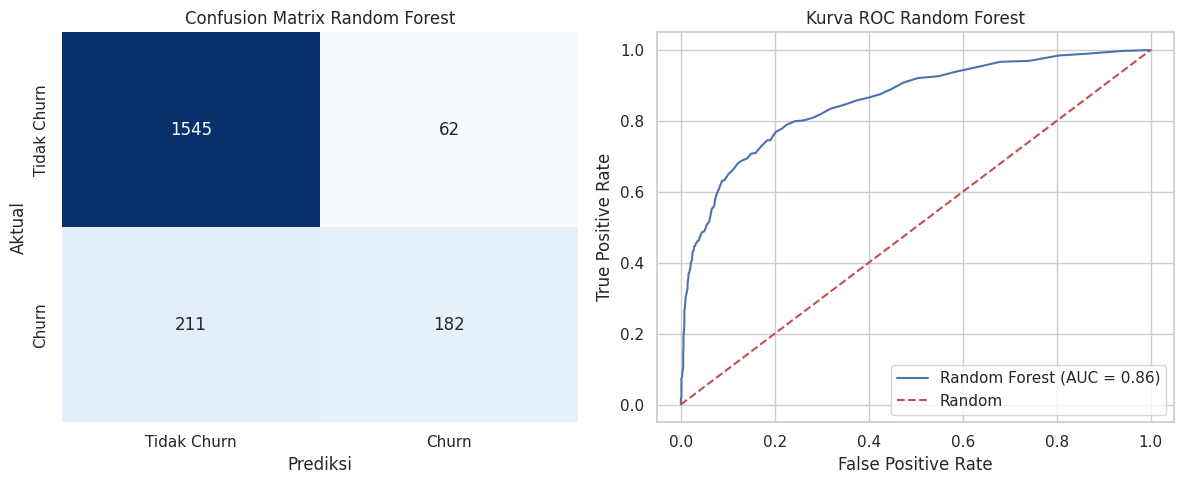


--- Evaluasi Model XGBoost ---
Akurasi: 0.8580
Presisi: 0.6940
Recall: 0.4962
F1-Score: 0.5786
ROC-AUC: 0.8477


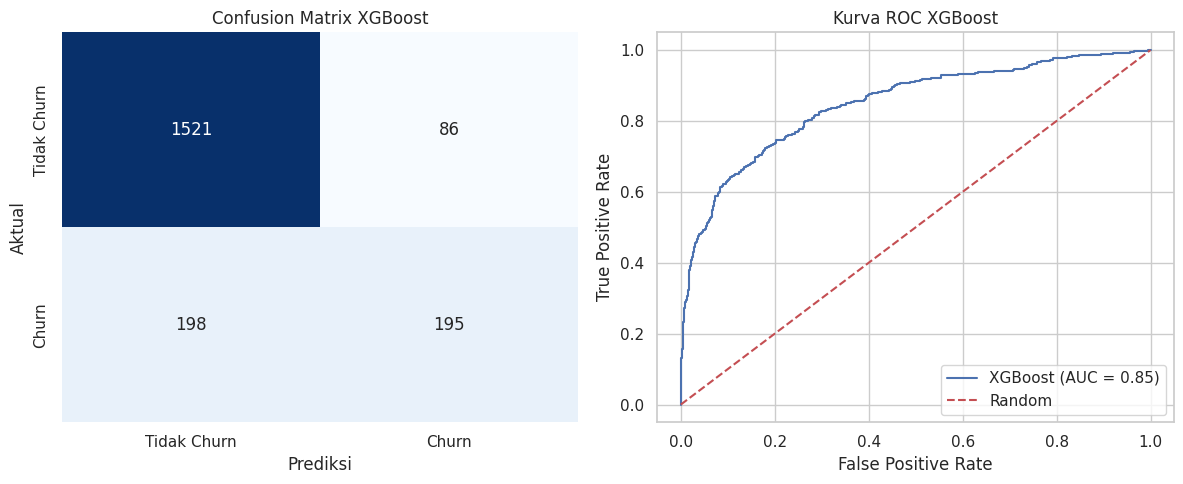

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Fungsi untuk evaluasi dan plot
def evaluate_and_plot(model_name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n--- Evaluasi Model {model_name} ---")
    print(f"Akurasi: {accuracy:.4f}")
    print(f"Presisi: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    plt.figure(figsize=(12, 5))

    # Confusion Matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Tidak Churn', 'Churn'], yticklabels=['Tidak Churn', 'Churn'])
    plt.title(f'Confusion Matrix {model_name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')

    # ROC Curve
    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'r--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Kurva ROC {model_name}')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Evaluasi Random Forest
if 'y_pred_rf' in globals() and 'churn_probabilities_rf_test' in globals():
    evaluate_and_plot('Random Forest', y_test, y_pred_rf, churn_probabilities_rf_test)
else:
    print("Variabel 'y_pred_rf' atau 'churn_probabilities_rf_test' tidak ditemukan. Pastikan sel pelatihan model sudah dijalankan.")

# Evaluasi XGBoost
if 'y_pred_xgb' in globals() and 'churn_probabilities_xgb_test' in globals():
    evaluate_and_plot('XGBoost', y_test, y_pred_xgb, churn_probabilities_xgb_test)
else:
    print("Variabel 'y_pred_xgb' atau 'churn_probabilities_xgb_test' tidak ditemukan. Pastikan sel pelatihan model sudah dijalankan.")


## Interpretasi Model dengan SHAP

--- Interpretasi Model dengan SHAP (Metode Sat-Set 1000 Sample) ---

--- Processing Random Forest SHAP ---


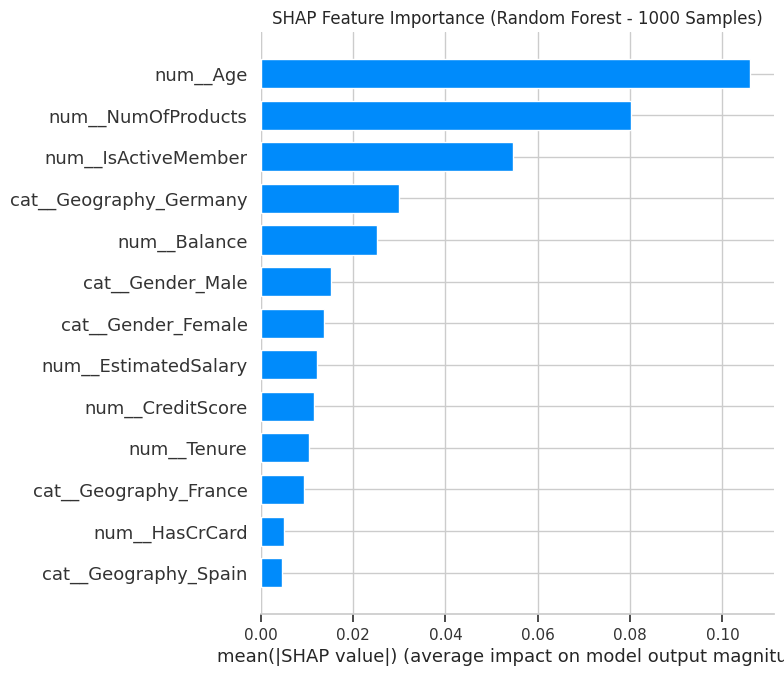

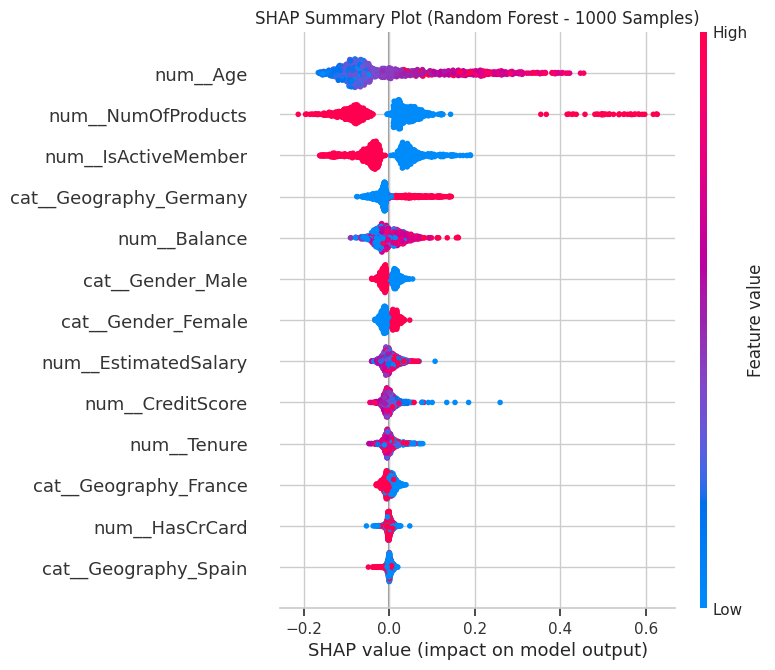


--- Processing XGBoost SHAP ---


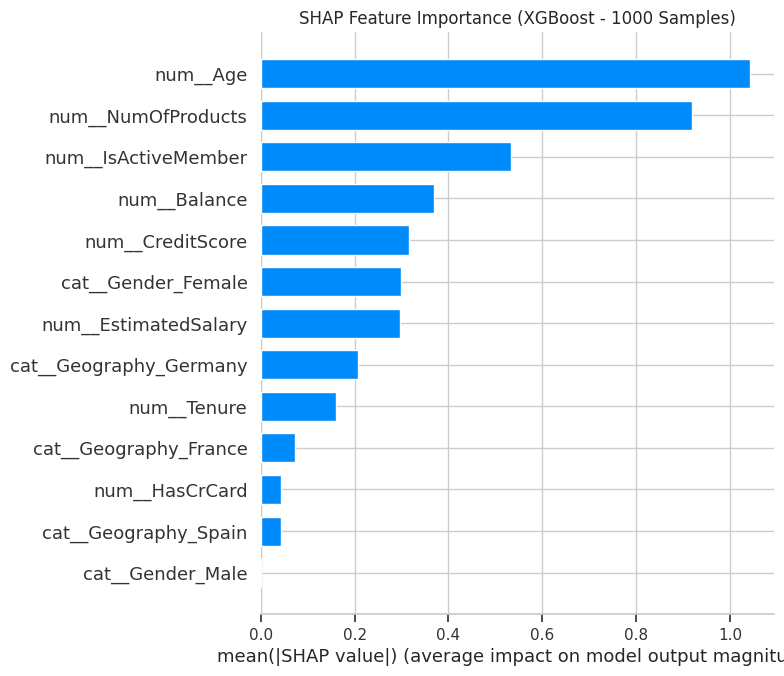

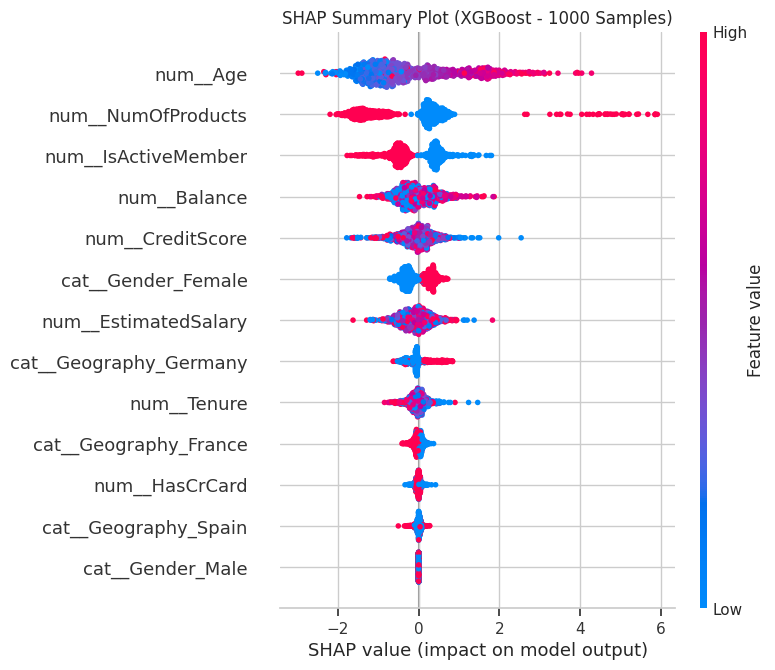

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

print("--- Interpretasi Model dengan SHAP (Metode Sat-Set 1000 Sample) ---")

# 1. Pastikan model & preprocessor ada
if 'preprocessor' in globals() and 'random_forest_model_pipeline' in globals() and 'xgboost_model_pipeline' in globals():

    # Ambil Preprocessor dan Model
    current_preprocessor = random_forest_model_pipeline.named_steps['preprocessor']
    current_classifier_rf = random_forest_model_pipeline.named_steps['classifier']
    current_classifier_xgb = xgboost_model_pipeline.named_steps['classifier']

    # 2. Transformasi data X_test & bikin DataFrame
    X_test_transformed = current_preprocessor.transform(X_test)
    feature_names = current_preprocessor.get_feature_names_out()
    X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

    # 3. AMBIL 1000 SAMPLE SECARA ACAK
    X_test_sample = X_test_transformed_df.sample(n=1000, random_state=42)

    # Bagian Random Forest
    print("\n--- Processing Random Forest SHAP ---")
    explainer_rf = shap.TreeExplainer(current_classifier_rf)
    # Hitung SHAP khusus untuk sample 1000 saja
    shap_values_rf = explainer_rf.shap_values(X_test_sample, check_additivity=False)

    # Plot Bar (Importance)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_rf[:, :, 1], X_test_sample, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Random Forest - 1000 Samples)")
    plt.show()

    # Plot Dot (Summary)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_rf[:, :, 1], X_test_sample, show=False)
    plt.title("SHAP Summary Plot (Random Forest - 1000 Samples)")
    plt.show()

    # Bagian XGBoost
    print("\n--- Processing XGBoost SHAP ---")
    explainer_xgb = shap.TreeExplainer(current_classifier_xgb)
    # Hitung SHAP khusus untuk sample 1000 saja
    shap_values_xgb = explainer_xgb.shap_values(X_test_sample, check_additivity=False)

    # Plot Bar (Importance)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_xgb, X_test_sample, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (XGBoost - 1000 Samples)")
    plt.show()

    # Plot Dot (Summary)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_xgb, X_test_sample, show=False)
    plt.title("SHAP Summary Plot (XGBoost - 1000 Samples)")
    plt.show()

else:
    print("Error: Pastikan 'preprocessor', 'random_forest_model_pipeline', dan 'xgboost_model_pipeline' sudah di-run sebelumnya!")

## verifikasi dataset kalo kolom ke isi semua

In [ ]:
import pandas as pd

# Ensure df is loaded if it's not already in memory
if 'df' not in locals() and 'df' not in globals():
    try:
        df = pd.read_csv('Churn_Modelling.csv')
        print("Dataset 'Churn_Modelling.csv' loaded.")
    except FileNotFoundError:
        print("Error: 'Churn_Modelling.csv' not found. Please ensure the file is in the correct directory.")
        exit()

df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
